Iris Flower Classification

This project focuses on classifying iris flowers into different species using machine learning algorithms.

Importing necessary libraries for data handling and machine learning

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

Load Dataset

The Iris dataset is loaded using sklearn

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully")

Dataset loaded successfully


Data Understanding

In [3]:
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


The dataset contains features such as sepal length, sepal width, petal length and petal width. The target variable represents the species of the flower.

In [4]:
print(X[:5])   # first 5 inputs
print(y[:5])   # first 5 outputs

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Data Preparation

Converting the dataset into a DataFrame for better visualization and understanding.

In [5]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df['target'] = df['target'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", len(X_train))
print("Testing data size:", len(X_test))

Training data size: 120
Testing data size: 30


Model 1: Decision Tree Model

A Decision Tree classifier is used to classify the iris flowers based on feature values.

In [8]:
from sklearn.tree import DecisionTreeClassifier

# create model
model = DecisionTreeClassifier()

# train model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


Prediction

The trained model is used to predict the output for test data.

In [9]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:5])

Predictions: [1 0 2 1 1]


Model Evaluation

The performance of the model is evaluated using accuracy score.

In [10]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Model 2: Naive Bayes 

A Gaussian Naive Bayes classifier is used as a second model for comparison.

In [11]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

from sklearn.metrics import accuracy_score
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 1.0


In [12]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Decision Tree Accuracy: 1.0
Naive Bayes Accuracy: 1.0


Confusion Matrix

The confusion matrix shows how well the model predicts each class.

In [13]:
from sklearn.metrics import confusion_matrix

print("Decision Tree CM:\n", confusion_matrix(y_test, y_pred))
print("\nNaive Bayes CM:\n", confusion_matrix(y_test, y_pred_nb))

Decision Tree CM:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Naive Bayes CM:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Confusion Matrix Heatmap

A heatmap is used to visually represent the confusion matrix. It helps in understanding how well the model is performing by showing correct and incorrect predictions for each class.

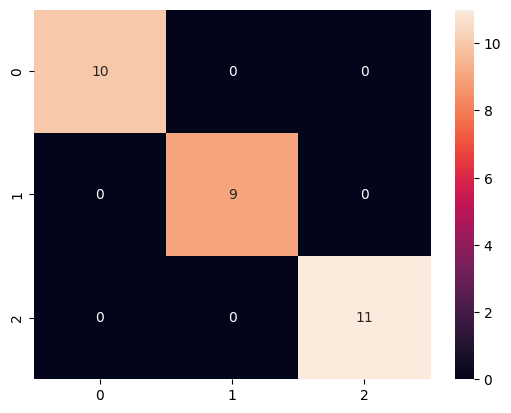

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

Conclusion

Both Decision Tree and Naive Bayes models achieved high accuracy on the Iris dataset. This is because the dataset is simple and well-structured. The models were able to effectively learn patterns and classify the flowers correctly.